# SIT720 8.1D — Sydney Housing Price Prediction and Decision Support System

## Machine Learning Mini Project

**Unit:** SIT720  
**Assessment:** 8.1D Distinction Task

### Project Objective

This project develops a machine learning-based system for predicting Sydney residential property sale prices. The project follows the machine learning lifecycle from data preparation and exploratory analysis through feature engineering, regression modelling, evaluation, prediction failure analysis, comparison with large language model and human estimates, and deployment of a prediction prototype.

The analysis focuses on three Sydney suburbs representing different housing-market contexts: Mosman, Parramatta and Blacktown.

## 1. Problem Definition and Dataset

The prediction target is the final residential property sale price. The dataset contains 105 sold properties distributed equally across three Sydney suburbs: Mosman, Parramatta and Blacktown, with 35 properties from each suburb.

The collected variables include suburb, property type, bedrooms, bathrooms, car spaces, land size, sale date and sale price. Property address and source information are retained for traceability and later investigation of prediction failures but are not used as predictive features.

The three suburbs were selected because they represent substantially different housing-market contexts. Differences in location, accessibility, housing stock and observed sale-price distributions provide useful variation for investigating whether machine learning can generalise across different local markets.

The dataset contains some missing values, particularly for land size and car spaces. Rather than manually inventing values, missing information is handled during model preprocessing. This preserves the original observations while allowing the models to operate on incomplete records.

Potential limitations include the relatively small sample size, uneven availability of property characteristics, differences in property type, potential selection bias in the collected listings, and the inability to capture important factors such as renovation quality, exact location, views, street characteristics and detailed property condition.

In [2]:
%pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,DATA_PATH = "../data/sydney_housing_realestate_105.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())
    r2_score
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
DATA_PATH = "../data/sydney_housing_realestate_105.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

Dataset loaded successfully!
Rows: 105
Columns: 10


,suburb,address,property_type,bedrooms,bathrooms,car_spaces,land_size,sale_date,sale_price,source_page
0,Mosman,5 Botanic Road,House,4,3,2.00,NaN,2026-07-22,8700000,https://www.realestate.com.au/sold/property-ho...
1,Mosman,105 Holt Avenue,House,4,3,NaN,NaN,2026-06-05,3550000,https://www.realestate.com.au/sold/property-ho...
2,Mosman,96 Glover Street,House,4,3,2.00,379.00,2026-06-02,3390000,https://www.realestate.com.au/sold/property-ho...
3,Mosman,14 Erith Street,House,4,3,1.00,613.00,2026-04-11,5300000,https://www.realestate.com.au/sold/property-ho...
4,Mosman,130 Cowles Road,House,5,2,1.00,NaN,2026-04-11,4200000,https://www.realestate.com.au/sold/property-ho...


In [3]:
print("Column names:")
print(df.columns.tolist())

print("\nDataset shape:")
print(df.shape)

print("\nData types:")
display(df.dtypes)

Column names:
['suburb', 'address', 'property_type', 'bedrooms', 'bathrooms', 'car_spaces', 'land_size', 'sale_date', 'sale_price', 'source_page']

Dataset shape:
(105, 10)

Data types:


suburb               str
address              str
property_type        str
bedrooms           int64
bathrooms          int64
car_spaces       float64
land_size        float64
sale_date            str
sale_price         int64
source_page          str
dtype: object

In [4]:
print("Missing values:")
display(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDuplicate addresses:", df["address"].duplicated().sum())

print("\nProperties by suburb:")
display(df["suburb"].value_counts())

Missing values:


suburb            0
address           0
property_type     0
bedrooms          0
bathrooms         0
car_spaces        9
land_size        27
sale_date         0
sale_price        0
source_page       0
dtype: int64


Duplicate rows: 0

Duplicate addresses: 0

Properties by suburb:


suburb
Mosman        35
Parramatta    35
Blacktown     35
Name: count, dtype: int64

In [5]:
df["sale_date"] = pd.to_datetime(
    df["sale_date"],
    errors="coerce"
)

numeric_columns = [
    "bedrooms",
    "bathrooms",
    "car_spaces",
    "land_size",
    "sale_price"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

print("Data types converted successfully.")

display(df.dtypes)

Data types converted successfully.


suburb                      str
address                     str
property_type               str
bedrooms                  int64
bathrooms                 int64
car_spaces              float64
land_size               float64
sale_date        datetime64[us]
sale_price                int64
source_page                 str
dtype: object

In [6]:
print("Overall numerical statistics:")
display(df.describe())

Overall numerical statistics:


,bedrooms,bathrooms,car_spaces,land_size,sale_date,sale_price
count,105.00,105.00,96.00,78.00,105,105.00
mean,3.79,2.09,2.01,532.61,2025-12-03 16:41:08.571428,"3,250,870.19"
min,2.00,1.00,1.00,143.00,2024-09-07 00:00:00,"770,000.00"
25%,3.00,1.00,1.00,449.50,2025-05-28 00:00:00,"1,150,000.00"
50%,3.00,2.00,2.00,556.00,2026-02-09 00:00:00,"1,672,000.00"
75%,5.00,3.00,2.00,621.35,2026-06-15 00:00:00,"3,900,000.00"
max,7.00,5.00,8.00,920.00,2026-08-10 00:00:00,"21,500,000.00"
std,1.13,1.03,1.12,167.43,NaN,"3,700,031.79"


In [7]:
suburb_summary = (
    df.groupby("suburb")["sale_price"]
      .agg(
          count="count",
          mean="mean",
          median="median",
          minimum="min",
          maximum="max"
      )
      .round(2)
)

display(suburb_summary)

,count,mean,median,minimum,maximum
suburb,,,,,
Blacktown,35,"1,123,342.34","1,040,000.00",820000,1881000
Mosman,35,"7,001,857.14","5,700,000.00",2907000,21500000
Parramatta,35,"1,627,411.09","1,620,000.00",770000,2360000


In [8]:
print("Property types:")
display(df["property_type"].value_counts())

Property types:


property_type
House                   99
Duplex/semi-detached     6
Name: count, dtype: int64

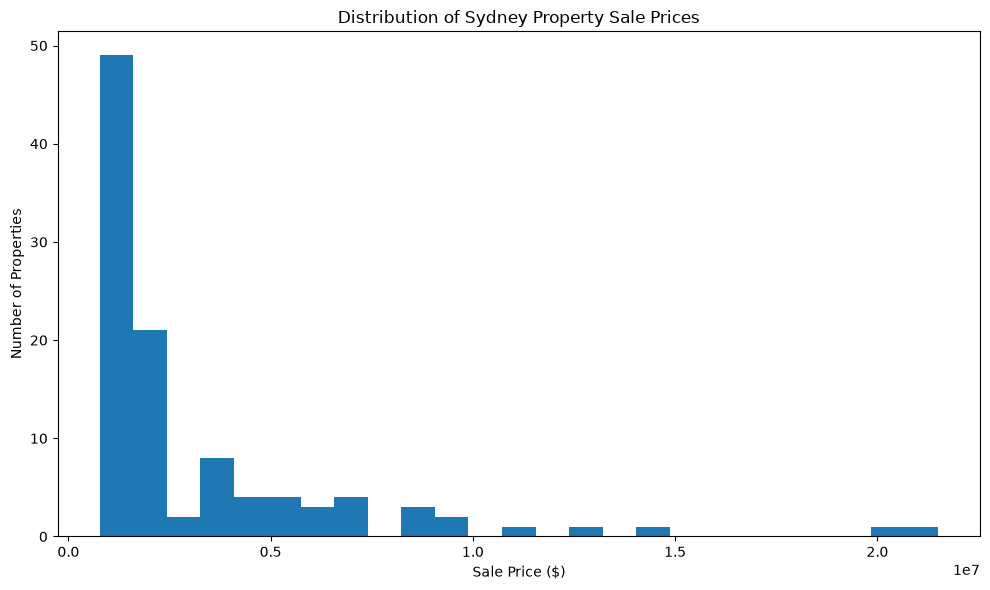

In [9]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["sale_price"],
    bins=25
)

plt.xlabel("Sale Price ($)")
plt.ylabel("Number of Properties")
plt.title("Distribution of Sydney Property Sale Prices")

plt.tight_layout()
plt.show()

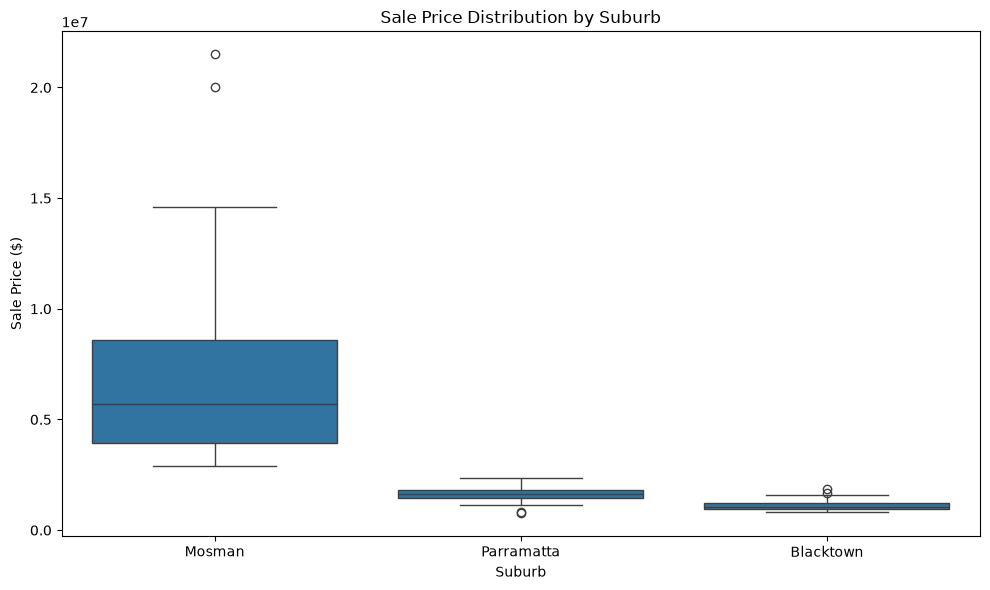

In [10]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="suburb",
    y="sale_price"
)

plt.xlabel("Suburb")
plt.ylabel("Sale Price ($)")
plt.title("Sale Price Distribution by Suburb")

plt.tight_layout()
plt.show()

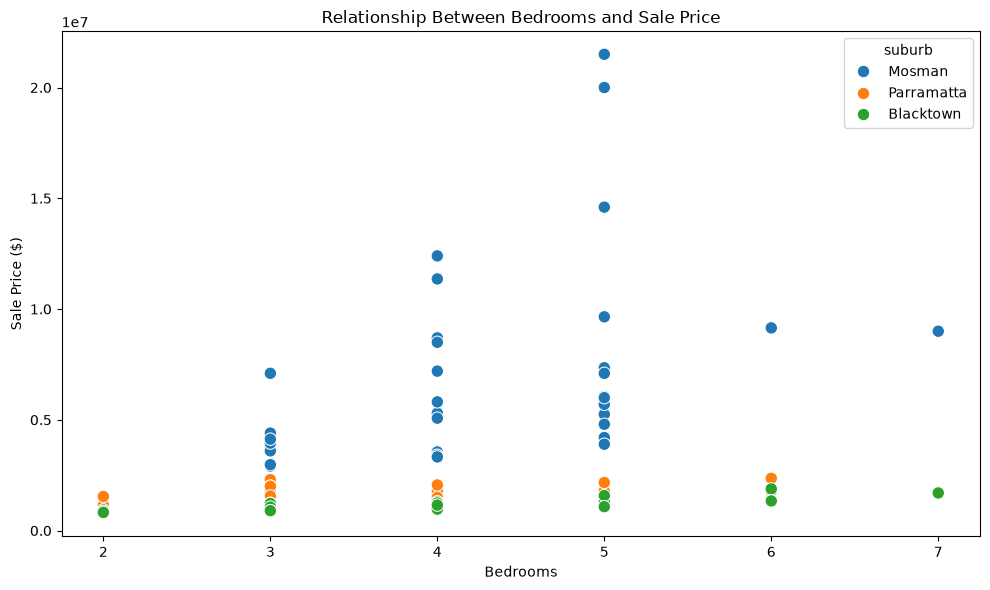

In [11]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="bedrooms",
    y="sale_price",
    hue="suburb",
    s=80
)

plt.xlabel("Bedrooms")
plt.ylabel("Sale Price ($)")
plt.title("Relationship Between Bedrooms and Sale Price")

plt.tight_layout()
plt.show()

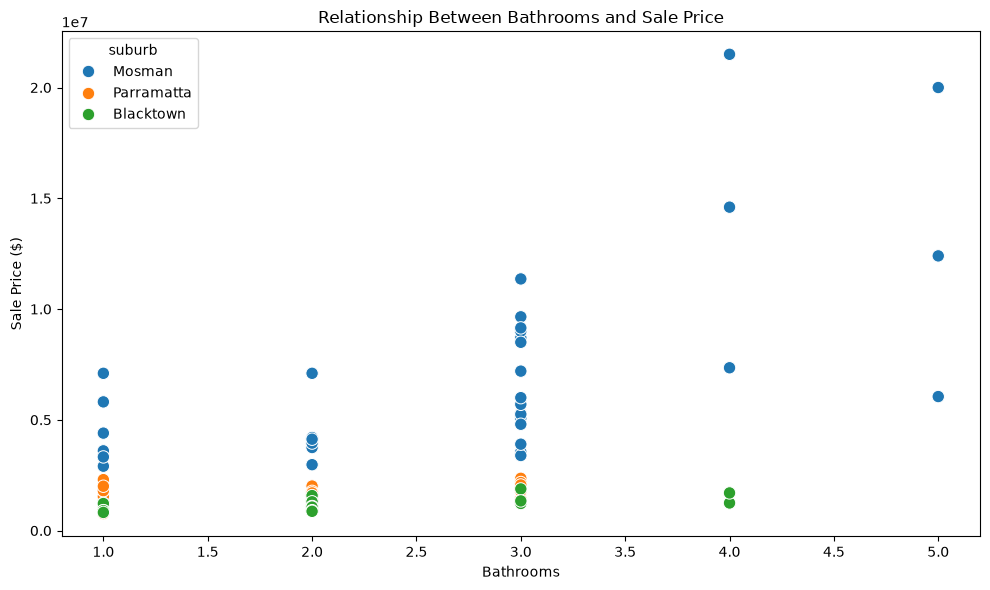

In [12]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="bathrooms",
    y="sale_price",
    hue="suburb",
    s=80
)

plt.xlabel("Bathrooms")
plt.ylabel("Sale Price ($)")
plt.title("Relationship Between Bathrooms and Sale Price")

plt.tight_layout()
plt.show()

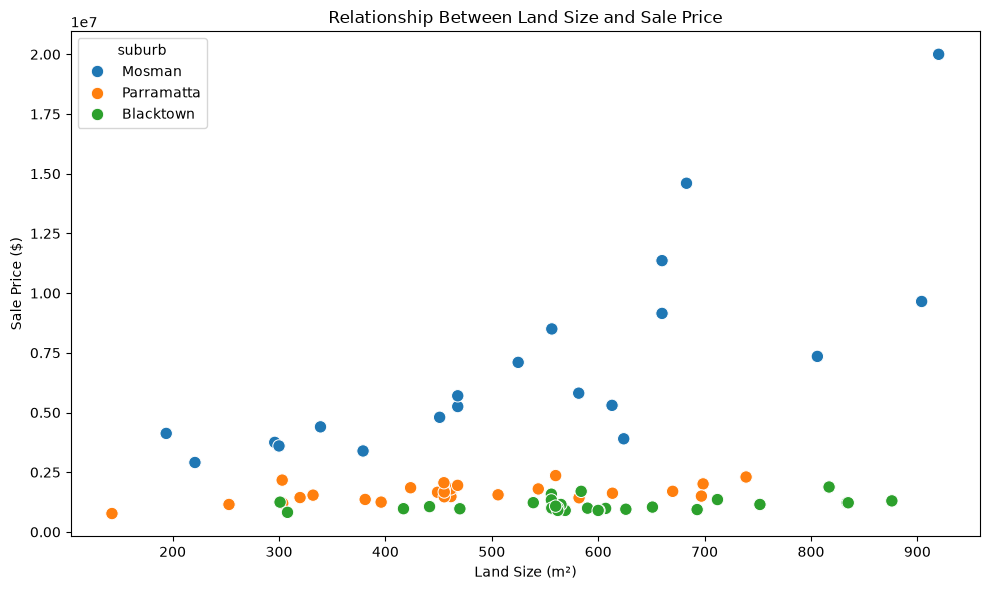

In [13]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="land_size",
    y="sale_price",
    hue="suburb",
    s=80
)

plt.xlabel("Land Size (m²)")
plt.ylabel("Sale Price ($)")
plt.title("Relationship Between Land Size and Sale Price")

plt.tight_layout()
plt.show()

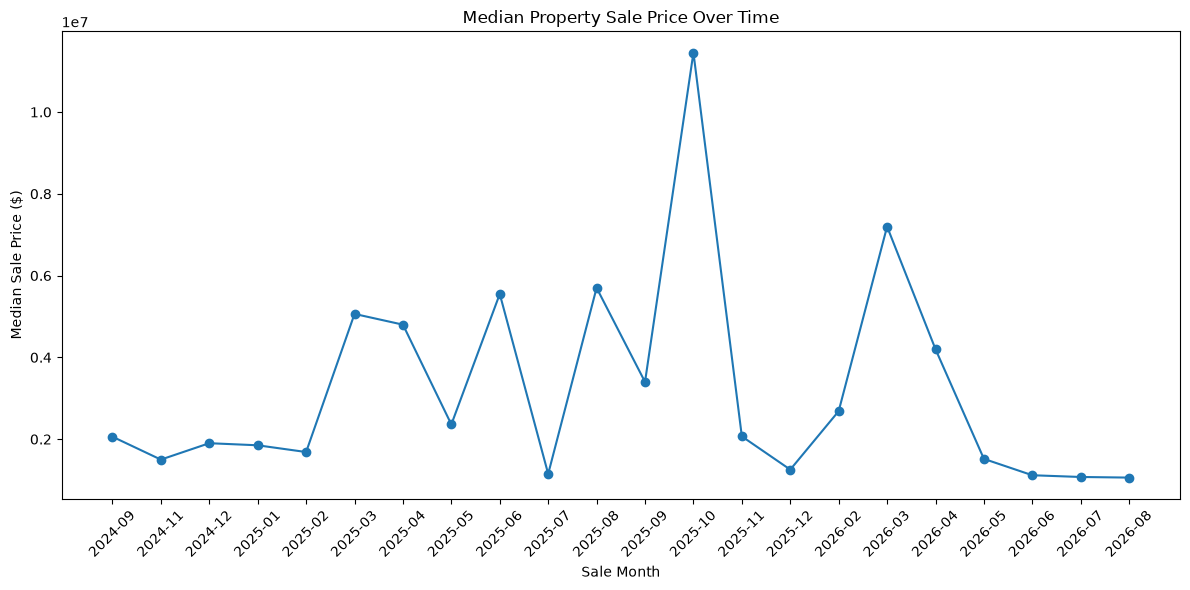

In [14]:
monthly_prices = (
    df.groupby(df["sale_date"].dt.to_period("M"))["sale_price"]
      .median()
      .reset_index()
)

monthly_prices["sale_month"] = (
    monthly_prices["sale_date"].astype(str)
)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_prices["sale_month"],
    monthly_prices["sale_price"],
    marker="o"
)

plt.xlabel("Sale Month")
plt.ylabel("Median Sale Price ($)")
plt.title("Median Property Sale Price Over Time")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [15]:
correlation_columns = [
    "bedrooms",
    "bathrooms",
    "car_spaces",
    "land_size",
    "sale_price"
]

correlation_matrix = df[
    correlation_columns
].corr()

display(correlation_matrix)

,bedrooms,bathrooms,car_spaces,land_size,sale_price
bedrooms,1.00,0.64,0.40,0.26,0.39
bathrooms,0.64,1.00,0.29,0.17,0.60
car_spaces,0.40,0.29,1.00,0.35,0.13
land_size,0.26,0.17,0.35,1.00,0.31
sale_price,0.39,0.60,0.13,0.31,1.00


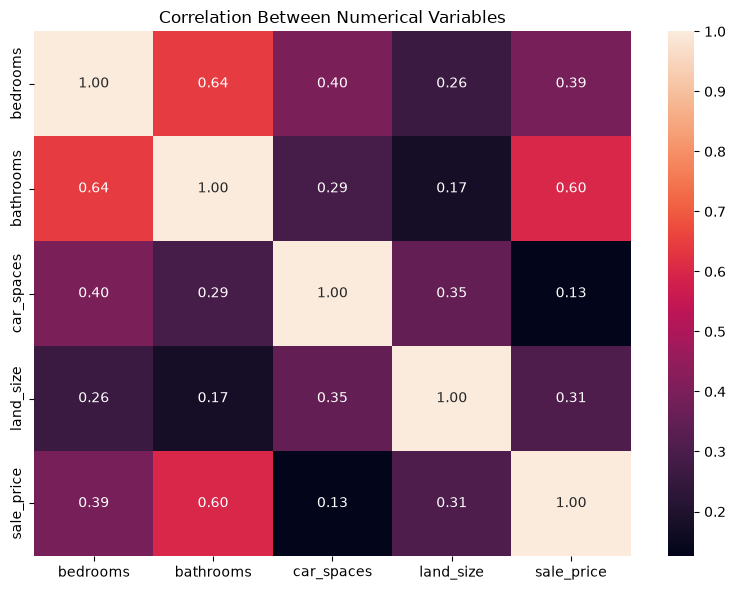

In [16]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Between Numerical Variables")

plt.tight_layout()
plt.show()

In [17]:
df["sale_year"] = df["sale_date"].dt.year
df["sale_month_num"] = df["sale_date"].dt.month

display(
    df[
        [
            "sale_date",
            "sale_year",
            "sale_month_num"
        ]
    ].head()
)

,sale_date,sale_year,sale_month_num
0,2026-07-22,2026,7
1,2026-06-05,2026,6
2,2026-06-02,2026,6
3,2026-04-11,2026,4
4,2026-04-11,2026,4


In [18]:
df["log_land_size"] = np.log1p(
    df["land_size"]
)

df["bathrooms_per_bedroom"] = (
    df["bathrooms"] /
    df["bedrooms"].replace(0, np.nan)
)

df["total_basic_features"] = (
    df["bedrooms"] +
    df["bathrooms"] +
    df["car_spaces"]
)

print("Feature engineering completed.")

display(
    df[
        [
            "suburb",
            "bedrooms",
            "bathrooms",
            "car_spaces",
            "land_size",
            "log_land_size",
            "bathrooms_per_bedroom",
            "total_basic_features",
            "sale_price"
        ]
    ].head()
)

Feature engineering completed.


,suburb,bedrooms,bathrooms,car_spaces,land_size,log_land_size,bathrooms_per_bedroom,total_basic_features,sale_price
0,Mosman,4,3,2.00,NaN,NaN,0.75,9.00,8700000
1,Mosman,4,3,NaN,NaN,NaN,0.75,NaN,3550000
2,Mosman,4,3,2.00,379.00,5.94,0.75,9.00,3390000
3,Mosman,4,3,1.00,613.00,6.42,0.75,8.00,5300000
4,Mosman,5,2,1.00,NaN,NaN,0.40,8.00,4200000


In [19]:
Q1 = df["sale_price"].quantile(0.25)
Q3 = df["sale_price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["sale_price"] < lower_bound) |
    (df["sale_price"] > upper_bound)
].copy()

print(f"Lower boundary: ${lower_bound:,.0f}")
print(f"Upper boundary: ${upper_bound:,.0f}")
print(f"Number of potential price outliers: {len(outliers)}")

display(
    outliers[
        [
            "address",
            "suburb",
            "property_type",
            "bedrooms",
            "bathrooms",
            "land_size",
            "sale_price"
        ]
    ].sort_values(
        "sale_price",
        ascending=False
    )
)

Lower boundary: $-2,975,000
Upper boundary: $8,025,000
Number of potential price outliers: 10


,address,suburb,property_type,bedrooms,bathrooms,land_size,sale_price
21,37 Carrington Avenue,Mosman,House,5,4,NaN,21500000
12,40 Stanley Avenue,Mosman,House,5,5,920.00,20000000
30,99 Muston Street,Mosman,House,5,4,683.00,14600000
27,2 Edwards Bay Road,Mosman,House,4,5,NaN,12400000
18,5 The Grove,Mosman,House,4,3,660.00,11360000
22,67 Raglan Street,Mosman,House,5,3,904.00,9650000
23,217 Raglan Street,Mosman,House,6,3,660.00,9150000
5,34 Rickard Avenue,Mosman,House,7,3,NaN,9000000
0,5 Botanic Road,Mosman,House,4,3,NaN,8700000
6,10 Cyprian Street,Mosman,House,4,3,556.40,8500000


In [20]:
feature_correlations = (
    correlation_matrix["sale_price"]
    .drop("sale_price")
    .abs()
    .sort_values(ascending=False)
)

print("Absolute correlations with sale price:")
display(feature_correlations)

Absolute correlations with sale price:


bathrooms    0.60
bedrooms     0.39
land_size    0.31
car_spaces   0.13
Name: sale_price, dtype: float64

## 2.1 Initial Feature Expectations

The exploratory analysis indicates that location is likely to be one of the strongest predictors of property value. The median sale price differs substantially between the three selected suburbs, with Blacktown at approximately $1.04 million, Parramatta at approximately $1.62 million, and Mosman at approximately $5.70 million. This large difference suggests that suburb captures important market-level variation.

Among the numerical variables, bathrooms shows the strongest correlation with sale price (approximately r = 0.60), followed by bedrooms (r = 0.39) and land size (r = 0.31). Therefore, the three variables initially expected to have the strongest influence are **suburb, bathrooms and bedrooms**.

Land size is also potentially important despite its lower simple correlation because its relationship with price may be nonlinear and may interact with suburb. This will be investigated through the subsequent machine learning models.

These expectations are based on exploratory evidence and will be evaluated against the model results rather than assumed to be correct in advance.

## 2.2 Outlier Analysis

The IQR-based analysis identified 10 observations above the upper price boundary of approximately $8.025 million. These observations are concentrated in Mosman and represent high-value properties.

The largest observed sale was 37 Carrington Avenue at $21.5 million, followed by 40 Stanley Avenue at $20.0 million and 99 Muston Street at $14.6 million.

These observations have not been automatically removed because a high sale price does not necessarily indicate an erroneous observation. They may represent genuine premium properties within the selected market. Removing them solely because they are statistically unusual could eliminate important information about the range of property values.

However, their presence may influence regression performance because the dataset contains only a small number of very high-value properties. This limitation is considered when interpreting model performance and prediction failures.

In [21]:
# Features used for prediction
feature_columns = [
    "suburb",
    "property_type",
    "bedrooms",
    "bathrooms",
    "car_spaces",
    "land_size",
    "sale_year",
    "sale_month_num",
    "log_land_size",
    "bathrooms_per_bedroom",
    "total_basic_features"
]

X = df[feature_columns].copy()
y = df["sale_price"].copy()

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

Features:


,suburb,property_type,bedrooms,bathrooms,car_spaces,land_size,sale_year,sale_month_num,log_land_size,bathrooms_per_bedroom,total_basic_features
0,Mosman,House,4,3,2.00,NaN,2026,7,NaN,0.75,9.00
1,Mosman,House,4,3,NaN,NaN,2026,6,NaN,0.75,NaN
2,Mosman,House,4,3,2.00,379.00,2026,6,5.94,0.75,9.00
3,Mosman,House,4,3,1.00,613.00,2026,4,6.42,0.75,8.00
4,Mosman,House,5,2,1.00,NaN,2026,4,NaN,0.40,8.00



Target:


0    8700000
1    3550000
2    3390000
3    5300000
4    4200000
Name: sale_price, dtype: int64

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

print("\nTraining target mean:", f"${y_train.mean():,.0f}")
print("Testing target mean:", f"${y_test.mean():,.0f}")

Training observations: 84
Testing observations: 21

Training target mean: $2,972,670
Testing target mean: $4,363,669


In [23]:
categorical_features = [
    "suburb",
    "property_type"
]

numeric_features = [
    "bedrooms",
    "bathrooms",
    "car_spaces",
    "land_size",
    "sale_year",
    "sale_month_num",
    "log_land_size",
    "bathrooms_per_bedroom",
    "total_basic_features"
]

numeric_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_preprocessor, numeric_features),
        ("categorical", categorical_preprocessor, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [24]:
models = {
    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=42
    ),

    "Gradient Boosting": HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=15,
        l2_regularization=1.0,
        random_state=42
    )
}

pipelines = {}

for name, model in models.items():
    pipelines[name] = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

print("Models ready:")
for name in pipelines:
    print("✓", name)

Models ready:
✓ Linear Regression
✓ Random Forest
✓ Gradient Boosting


In [25]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

cv_results = []

for name, pipeline in pipelines.items():

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=True
    )

    cv_results.append({
        "Model": name,
        "CV_MAE": -scores["test_MAE"].mean(),
        "CV_RMSE": -scores["test_RMSE"].mean(),
        "CV_R2": scores["test_R2"].mean(),
        "Train_R2": scores["train_R2"].mean()
    })

results_df = pd.DataFrame(cv_results)

results_df = results_df.sort_values(
    "CV_RMSE"
).reset_index(drop=True)

display(results_df)

,Model,CV_MAE,CV_RMSE,CV_R2,Train_R2
0,Random Forest,"856,101.87","1,672,629.33",0.71,0.85
1,Gradient Boosting,"1,133,340.26","1,757,580.38",0.64,0.73
2,Linear Regression,"1,220,763.13","1,873,375.54",0.60,0.69


## 3.1 Cross-Validation Results and Model Comparison

Five-fold cross-validation was used to compare the three regression approaches. Random Forest achieved the strongest cross-validated performance, obtaining a mean MAE of approximately $856,102, RMSE of approximately $1.67 million and R² of 0.71. Gradient Boosting achieved an R² of 0.64, while Linear Regression achieved an R² of 0.60.

The results support the initial expectation that an ensemble-based nonlinear model would capture the relationships in the housing data more effectively than a simple linear model. Random Forest produced both the lowest prediction errors and the highest cross-validated R².

The Random Forest training R² of 0.85 compared with its cross-validated R² of 0.71 indicates a noticeable generalisation gap. This suggests some overfitting, meaning the model captures patterns specific to the training observations that do not transfer completely to unseen folds. Nevertheless, the cross-validation results indicate that Random Forest provides the strongest predictive performance among the three evaluated approaches for this dataset.

The relatively large RMSE values should also be interpreted in the context of the dataset. The selected suburbs have substantially different price levels and the dataset contains several high-value Mosman properties. Large errors on these expensive properties can have a strong effect on RMSE.

In [26]:
trained_models = {}

test_results = []

for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    trained_models[name] = pipeline

    test_results.append({
        "Model": name,
        "Test_MAE": mae,
        "Test_RMSE": rmse,
        "Test_R2": r2
    })

test_results_df = pd.DataFrame(test_results)

test_results_df = test_results_df.sort_values(
    "Test_RMSE"
).reset_index(drop=True)

display(test_results_df)

,Model,Test_MAE,Test_RMSE,Test_R2
0,Random Forest,"1,336,985.05","2,584,615.04",0.74
1,Linear Regression,"1,663,262.39","2,804,245.78",0.69
2,Gradient Boosting,"1,730,746.59","3,022,218.31",0.64


In [47]:
# Select final model using cross-validation results
# The held-out test set is reserved for final evaluation.

best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Final model selected using cross-validation:")
print(best_model_name)

Final model selected using cross-validation:
Random Forest


In [48]:
best_predictions = best_model.predict(X_test)

prediction_results = X_test.copy()

prediction_results["Actual_Price"] = y_test.values
prediction_results["Predicted_Price"] = best_predictions

prediction_results["Absolute_Error"] = abs(
    prediction_results["Actual_Price"] -
    prediction_results["Predicted_Price"]
)

prediction_results["Percentage_Error"] = (
    prediction_results["Absolute_Error"] /
    prediction_results["Actual_Price"]
) * 100

display(
    prediction_results.sort_values(
        "Absolute_Error",
        ascending=False
    ).head(10)
)

,suburb,property_type,bedrooms,bathrooms,car_spaces,land_size,sale_year,sale_month_num,log_land_size,bathrooms_per_bedroom,total_basic_features,Actual_Price,Predicted_Price,Absolute_Error,Percentage_Error
12,Mosman,House,5,5,2.00,920.00,2025,10,6.83,1.00,12.00,20000000,"10,026,639.26","9,973,360.74",49.87
30,Mosman,House,5,4,4.00,683.00,2025,4,6.53,0.80,13.00,14600000,"10,809,989.26","3,790,010.74",25.96
0,Mosman,House,4,3,2.00,NaN,2026,7,NaN,0.75,9.00,8700000,"4,928,268.12","3,771,731.88",43.35
18,Mosman,House,4,3,4.00,660.00,2025,8,6.49,0.75,11.00,11360000,"9,687,265.77","1,672,734.23",14.72
10,Mosman,House,3,2,1.00,296.00,2026,2,5.69,0.67,6.00,3750000,"5,420,304.41","1,670,304.41",44.54
4,Mosman,House,5,2,1.00,NaN,2026,4,NaN,0.40,8.00,4200000,"5,839,039.32","1,639,039.32",39.02
33,Mosman,Duplex/semi-detached,3,2,2.00,194.00,2025,3,5.27,0.67,7.00,4125000,"5,310,045.55","1,185,045.55",28.73
31,Mosman,House,5,3,2.00,451.00,2025,4,6.11,0.60,10.00,4800000,"5,895,753.35","1,095,753.35",22.83
53,Parramatta,House,2,1,NaN,NaN,2025,5,NaN,0.50,NaN,830000,"1,496,449.56","666,449.56",80.30
65,Parramatta,House,3,1,2.00,NaN,2024,12,NaN,0.33,6.00,2002000,"1,356,065.11","645,934.89",32.26


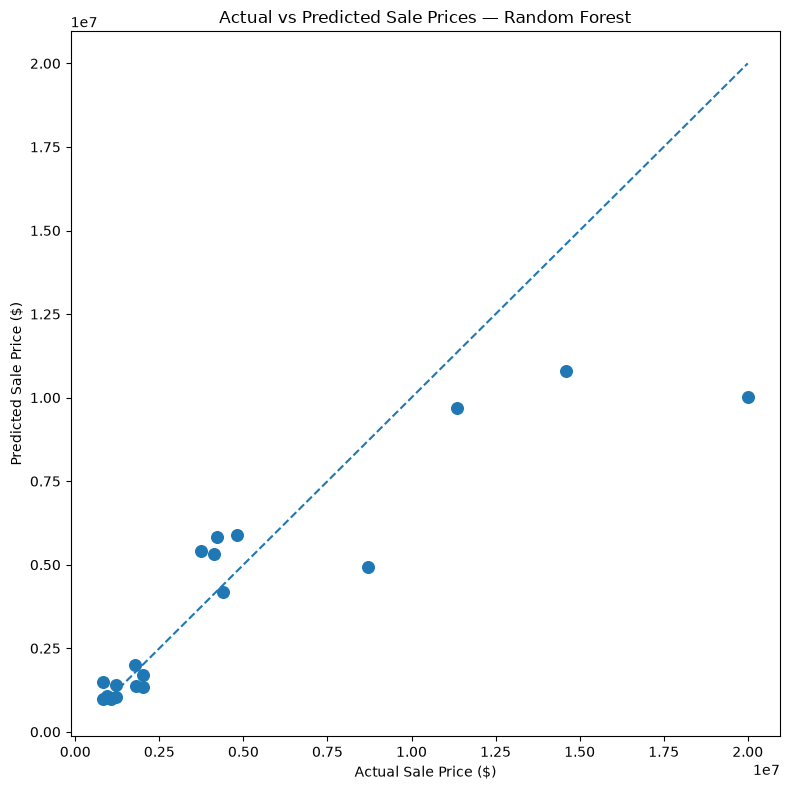

In [43]:
plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    best_predictions,
    s=70
)

min_price = min(
    y_test.min(),
    best_predictions.min()
)

max_price = max(
    y_test.max(),
    best_predictions.max()
)

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.xlabel("Actual Sale Price ($)")
plt.ylabel("Predicted Sale Price ($)")
plt.title(
    f"Actual vs Predicted Sale Prices — {best_model_name}"
)

plt.tight_layout()
plt.show()

In [30]:
largest_errors = (
    prediction_results
    .sort_values(
        "Absolute_Error",
        ascending=False
    )
    .head(5)
    .copy()
)

failure_columns = [
    "address" if "address" in prediction_results.columns else None,
    "suburb",
    "property_type",
    "bedrooms",
    "bathrooms",
    "car_spaces",
    "land_size",
    "Actual_Price",
    "Predicted_Price",
    "Absolute_Error",
    "Percentage_Error"
]

failure_columns = [
    col for col in failure_columns
    if col is not None and col in largest_errors.columns
]

display(largest_errors[failure_columns])

,suburb,property_type,bedrooms,bathrooms,car_spaces,land_size,Actual_Price,Predicted_Price,Absolute_Error,Percentage_Error
12,Mosman,House,5,5,2.00,920.00,20000000,"10,026,639.26","9,973,360.74",49.87
30,Mosman,House,5,4,4.00,683.00,14600000,"10,809,989.26","3,790,010.74",25.96
0,Mosman,House,4,3,2.00,NaN,8700000,"4,928,268.12","3,771,731.88",43.35
18,Mosman,House,4,3,4.00,660.00,11360000,"9,687,265.77","1,672,734.23",14.72
10,Mosman,House,3,2,1.00,296.00,3750000,"5,420,304.41","1,670,304.41",44.54


In [31]:
# Part 4 — Detailed investigation of the five largest prediction errors

# Recover the original property details using the test-set indices
failure_details = df.loc[
    y_test.index,
    [
        "address",
        "suburb",
        "property_type",
        "bedrooms",
        "bathrooms",
        "car_spaces",
        "land_size",
        "sale_date"
    ]
].copy()

failure_details["Actual_Price"] = y_test
failure_details["Predicted_Price"] = best_predictions

failure_details["Absolute_Error"] = (
    failure_details["Actual_Price"] -
    failure_details["Predicted_Price"]
).abs()

failure_details["Percentage_Error"] = (
    failure_details["Absolute_Error"] /
    failure_details["Actual_Price"]
) * 100

largest_errors_detailed = (
    failure_details
    .sort_values("Absolute_Error", ascending=False)
    .head(5)
)

display(largest_errors_detailed)

,address,suburb,property_type,bedrooms,bathrooms,car_spaces,land_size,sale_date,Actual_Price,Predicted_Price,Absolute_Error,Percentage_Error
12,40 Stanley Avenue,Mosman,House,5,5,2.00,920.00,2025-10-09,20000000,"10,026,639.26","9,973,360.74",49.87
30,99 Muston Street,Mosman,House,5,4,4.00,683.00,2025-04-06,14600000,"10,809,989.26","3,790,010.74",25.96
0,5 Botanic Road,Mosman,House,4,3,2.00,NaN,2026-07-22,8700000,"4,928,268.12","3,771,731.88",43.35
18,5 The Grove,Mosman,House,4,3,4.00,660.00,2025-08-16,11360000,"9,687,265.77","1,672,734.23",14.72
10,1 Bray Street,Mosman,House,3,2,1.00,296.00,2026-02-27,3750000,"5,420,304.41","1,670,304.41",44.54


# Part 4 — Investigation of Prediction Failures

The five largest prediction errors were concentrated in Mosman and involved relatively high-value properties. The largest error occurred for 40 Stanley Avenue, where the actual sale price was $20.0 million while the Random Forest predicted approximately $10.03 million. The model therefore underestimated this property by approximately $9.97 million.

The other large errors also involved premium Mosman properties. For example, 99 Muston Street had an actual sale price of $14.6 million compared with a predicted price of approximately $10.81 million, while 5 Botanic Road had an actual price of $8.7 million compared with a prediction of approximately $4.93 million.

A common characteristic of these failures is that the available predictive features describe basic structural characteristics but do not capture many factors that can cause very large differences in premium property prices. Features such as exact location, views, renovation quality, architectural characteristics, property condition, building area and local accessibility were not available in the dataset.

The model also overestimated 1 Bray Street, which had an actual price of $3.75 million and a predicted price of approximately $5.42 million. This demonstrates that the model can also overestimate properties when their characteristics resemble more expensive observations in the training data.

These failures suggest that the model should be used cautiously for unusual, luxury or high-value properties. The relatively small dataset and concentration of extreme observations in Mosman make it difficult for the model to learn the full range of premium property characteristics.

In [32]:
# Part 5 — Select 10 properties from the held-out test set

part5_properties = failure_details.copy()

# Select 10 test-set properties with a spread across price levels
part5_properties = (
    part5_properties
    .sort_values("Actual_Price")
)

# Select 10 evenly distributed observations
indices = np.linspace(
    0,
    len(part5_properties) - 1,
    10,
    dtype=int
)

part5_sample = part5_properties.iloc[indices].copy()

# Add columns for the two comparison estimates
part5_sample["LLM_Prediction"] = np.nan
part5_sample["Human_Prediction"] = np.nan

display(
    part5_sample[
        [
            "address",
            "suburb",
            "property_type",
            "bedrooms",
            "bathrooms",
            "car_spaces",
            "land_size",
            "Actual_Price",
            "Predicted_Price",
            "LLM_Prediction",
            "Human_Prediction"
        ]
    ]
)

,address,suburb,property_type,bedrooms,bathrooms,car_spaces,land_size,Actual_Price,Predicted_Price,LLM_Prediction,Human_Prediction
104,1 Tara Road,Blacktown,House,2,1,2.00,308.00,820000,"980,101.17",NaN,NaN
89,40 Balmoral Street,Blacktown,House,2,1,2.00,693.00,936000,"1,078,608.25",NaN,NaN
80,28 Reservoir Road,Blacktown,House,3,2,2.00,651.00,1040000,"1,014,791.56",NaN,NaN
96,57 Walters Road,Blacktown,House,3,1,1.00,835.00,1221000,"1,051,692.36",NaN,NaN
47,9 Carrington Street,Parramatta,House,5,3,2.00,455.00,1785000,"2,001,357.64",NaN,NaN
45,38 Inkerman Street,Parramatta,House,3,2,4.00,698.60,2010500,"1,688,235.43",NaN,NaN
33,69 Belmont Road,Mosman,Duplex/semi-detached,3,2,2.00,194.00,4125000,"5,310,045.55",NaN,NaN
26,5 Keston Avenue,Mosman,House,3,1,1.00,339.00,4400000,"4,183,787.78",NaN,NaN
0,5 Botanic Road,Mosman,House,4,3,2.00,NaN,8700000,"4,928,268.12",NaN,NaN
12,40 Stanley Avenue,Mosman,House,5,5,2.00,920.00,20000000,"10,026,639.26",NaN,NaN


In [44]:
# Part 5 — Information provided to the LLM

llm_input = part5_sample[
    [
        "suburb",
        "property_type",
        "bedrooms",
        "bathrooms",
        "car_spaces",
        "land_size"
    ]
].copy()

display(llm_input)

,suburb,property_type,bedrooms,bathrooms,car_spaces,land_size
104,Blacktown,House,2,1,2.00,308.00
89,Blacktown,House,2,1,2.00,693.00
80,Blacktown,House,3,2,2.00,651.00
96,Blacktown,House,3,1,1.00,835.00
47,Parramatta,House,5,3,2.00,455.00
45,Parramatta,House,3,2,4.00,698.60
33,Mosman,Duplex/semi-detached,3,2,2.00,194.00
26,Mosman,House,3,1,1.00,339.00
0,Mosman,House,4,3,2.00,NaN
12,Mosman,House,5,5,2.00,920.00


In [45]:
# Part 5 — Add LLM predictions

llm_predictions = [
    1050000,
    1250000,
    1350000,
    1400000,
    2100000,
    1750000,
    2000000,
    2250000,
    2700000,
    4000000
]

part5_sample["LLM_Prediction"] = llm_predictions

display(
    part5_sample[
        [
            "address",
            "suburb",
            "property_type",
            "bedrooms",
            "bathrooms",
            "car_spaces",
            "land_size",
            "Actual_Price",
            "Predicted_Price",
            "LLM_Prediction"
        ]
    ]
)

,address,suburb,property_type,bedrooms,bathrooms,car_spaces,land_size,Actual_Price,Predicted_Price,LLM_Prediction
104,1 Tara Road,Blacktown,House,2,1,2.00,308.00,820000,"980,101.17",1050000
89,40 Balmoral Street,Blacktown,House,2,1,2.00,693.00,936000,"1,078,608.25",1250000
80,28 Reservoir Road,Blacktown,House,3,2,2.00,651.00,1040000,"1,014,791.56",1350000
96,57 Walters Road,Blacktown,House,3,1,1.00,835.00,1221000,"1,051,692.36",1400000
47,9 Carrington Street,Parramatta,House,5,3,2.00,455.00,1785000,"2,001,357.64",2100000
45,38 Inkerman Street,Parramatta,House,3,2,4.00,698.60,2010500,"1,688,235.43",1750000
33,69 Belmont Road,Mosman,Duplex/semi-detached,3,2,2.00,194.00,4125000,"5,310,045.55",2000000
26,5 Keston Avenue,Mosman,House,3,1,1.00,339.00,4400000,"4,183,787.78",2250000
0,5 Botanic Road,Mosman,House,4,3,2.00,NaN,8700000,"4,928,268.12",2700000
12,40 Stanley Avenue,Mosman,House,5,5,2.00,920.00,20000000,"10,026,639.26",4000000


In [46]:
# Part 5 — Add your own human estimates

human_predictions = [
    1100000,  # Property 1
    1300000,  # Property 2
    1400000,  # Property 3
    1450000,  # Property 4
    2200000,  # Property 5
    1800000,  # Property 6
    3000000,  # Property 7
    3000000,  # Property 8
    4000000,  # Property 9
    6000000   # Property 10
]

part5_sample["Human_Prediction"] = human_predictions

display(
    part5_sample[
        [
            "address",
            "suburb",
            "property_type",
            "bedrooms",
            "bathrooms",
            "car_spaces",
            "land_size",
            "Actual_Price",
            "Predicted_Price",
            "LLM_Prediction",
            "Human_Prediction"
        ]
    ]
)

,address,suburb,property_type,bedrooms,bathrooms,car_spaces,land_size,Actual_Price,Predicted_Price,LLM_Prediction,Human_Prediction
104,1 Tara Road,Blacktown,House,2,1,2.00,308.00,820000,"980,101.17",1050000,1100000
89,40 Balmoral Street,Blacktown,House,2,1,2.00,693.00,936000,"1,078,608.25",1250000,1300000
80,28 Reservoir Road,Blacktown,House,3,2,2.00,651.00,1040000,"1,014,791.56",1350000,1400000
96,57 Walters Road,Blacktown,House,3,1,1.00,835.00,1221000,"1,051,692.36",1400000,1450000
47,9 Carrington Street,Parramatta,House,5,3,2.00,455.00,1785000,"2,001,357.64",2100000,2200000
45,38 Inkerman Street,Parramatta,House,3,2,4.00,698.60,2010500,"1,688,235.43",1750000,1800000
33,69 Belmont Road,Mosman,Duplex/semi-detached,3,2,2.00,194.00,4125000,"5,310,045.55",2000000,3000000
26,5 Keston Avenue,Mosman,House,3,1,1.00,339.00,4400000,"4,183,787.78",2250000,3000000
0,5 Botanic Road,Mosman,House,4,3,2.00,NaN,8700000,"4,928,268.12",2700000,4000000
12,40 Stanley Avenue,Mosman,House,5,5,2.00,920.00,20000000,"10,026,639.26",4000000,6000000


In [36]:
# Part 5 — Compare ML, LLM and Human Estimates

comparison = part5_sample[
    [
        "address",
        "suburb",
        "Actual_Price",
        "Predicted_Price",
        "LLM_Prediction",
        "Human_Prediction"
    ]
].copy()

# Calculate absolute errors
comparison["ML_Absolute_Error"] = (
    comparison["Actual_Price"] - comparison["Predicted_Price"]
).abs()

comparison["LLM_Absolute_Error"] = (
    comparison["Actual_Price"] - comparison["LLM_Prediction"]
).abs()

comparison["Human_Absolute_Error"] = (
    comparison["Actual_Price"] - comparison["Human_Prediction"]
).abs()
    
# Calculate percentage errors
comparison["ML_Percentage_Error"] = (
    comparison["ML_Absolute_Error"] /
    comparison["Actual_Price"]
) * 100

comparison["LLM_Percentage_Error"] = (
    comparison["LLM_Absolute_Error"] /
    comparison["Actual_Price"]
) * 100

comparison["Human_Percentage_Error"] = (
    comparison["Human_Absolute_Error"] /
    comparison["Actual_Price"]
) * 100

# Overall MAE
mae_results = pd.DataFrame({
    "Approach": [
        "Random Forest ML",
        "LLM",
        "Human"
    ],
    "MAE": [
        comparison["ML_Absolute_Error"].mean(),
        comparison["LLM_Absolute_Error"].mean(),
        comparison["Human_Absolute_Error"].mean()
    ]
})

# Overall MAPE
mape_results = pd.DataFrame({
    "Approach": [
        "Random Forest ML",
        "LLM",
        "Human"
    ],
    "MAPE (%)": [
        comparison["ML_Percentage_Error"].mean(),
        comparison["LLM_Percentage_Error"].mean(),
        comparison["Human_Percentage_Error"].mean()
    ]
})

print("PROPERTY-LEVEL COMPARISON")
display(comparison.round(2))

print("\nOVERALL MAE")
display(mae_results.round(2))

print("\nOVERALL MAPE")
display(mape_results.round(2))

PROPERTY-LEVEL COMPARISON


,address,suburb,Actual_Price,Predicted_Price,LLM_Prediction,Human_Prediction,ML_Absolute_Error,LLM_Absolute_Error,Human_Absolute_Error,ML_Percentage_Error,LLM_Percentage_Error,Human_Percentage_Error
104,1 Tara Road,Blacktown,820000,"980,101.17",1050000,1100000,"160,101.17",230000,280000,19.52,28.05,34.15
89,40 Balmoral Street,Blacktown,936000,"1,078,608.25",1250000,1300000,"142,608.25",314000,364000,15.24,33.55,38.89
80,28 Reservoir Road,Blacktown,1040000,"1,014,791.56",1350000,1400000,"25,208.44",310000,360000,2.42,29.81,34.62
96,57 Walters Road,Blacktown,1221000,"1,051,692.36",1400000,1450000,"169,307.64",179000,229000,13.87,14.66,18.76
47,9 Carrington Street,Parramatta,1785000,"2,001,357.64",2100000,2200000,"216,357.64",315000,415000,12.12,17.65,23.25
45,38 Inkerman Street,Parramatta,2010500,"1,688,235.43",1750000,1800000,"322,264.57",260500,210500,16.03,12.96,10.47
33,69 Belmont Road,Mosman,4125000,"5,310,045.55",2000000,3000000,"1,185,045.55",2125000,1125000,28.73,51.52,27.27
26,5 Keston Avenue,Mosman,4400000,"4,183,787.78",2250000,3000000,"216,212.22",2150000,1400000,4.91,48.86,31.82
0,5 Botanic Road,Mosman,8700000,"4,928,268.12",2700000,4000000,"3,771,731.88",6000000,4700000,43.35,68.97,54.02
12,40 Stanley Avenue,Mosman,20000000,"10,026,639.26",4000000,6000000,"9,973,360.74",16000000,14000000,49.87,80.00,70.00



OVERALL MAE


,Approach,MAE
0,Random Forest ML,"1,618,219.81"
1,LLM,"2,788,350.00"
2,Human,"2,308,350.00"



OVERALL MAPE


,Approach,MAPE (%)
0,Random Forest ML,20.61
1,LLM,38.60
2,Human,34.32


In [37]:
# Save Part 5 comparison results

comparison.to_csv("../outputs/part5_comparison.csv", index=False)
mae_results.to_csv("../outputs/part5_mae_results.csv", index=False)
mape_results.to_csv("../outputs/part5_mape_results.csv", index=False)

print("Part 5 results saved successfully.")

Part 5 results saved successfully.


In [38]:
# Part 6 — Create Streamlit application

app_code = r'''
import streamlit as st
import pandas as pd
import numpy as np
import joblib

st.set_page_config(
    page_title="Sydney Housing Price Predictor",
    page_icon="🏠",
    layout="centered"
)

# Load trained model
model = joblib.load("../models/best_model.pkl")

st.title("🏠 Sydney Housing Price Prediction")
st.write(
    "Enter the basic characteristics of a Sydney property "
    "to obtain an estimated sale price."
)

st.sidebar.header("Property Information")

suburb = st.sidebar.selectbox(
    "Suburb",
    ["Blacktown", "Parramatta", "Mosman"]
)

property_type = st.sidebar.selectbox(
    "Property Type",
    ["House", "Duplex/semi-detached"]
)

bedrooms = st.sidebar.number_input(
    "Bedrooms",
    min_value=1,
    max_value=10,
    value=3,
    step=1
)

bathrooms = st.sidebar.number_input(
    "Bathrooms",
    min_value=1,
    max_value=10,
    value=2,
    step=1
)

car_spaces = st.sidebar.number_input(
    "Car Spaces",
    min_value=0,
    max_value=10,
    value=2,
    step=1
)

land_size = st.sidebar.number_input(
    "Land Size (m²)",
    min_value=50.0,
    max_value=5000.0,
    value=500.0,
    step=10.0
)

sale_year = st.sidebar.number_input(
    "Sale Year",
    min_value=2020,
    max_value=2030,
    value=2026,
    step=1
)

sale_month_num = st.sidebar.number_input(
    "Sale Month",
    min_value=1,
    max_value=12,
    value=9,
    step=1
)

# Engineered features
log_land_size = np.log1p(land_size)

bathrooms_per_bedroom = bathrooms / bedrooms

total_basic_features = bedrooms + bathrooms + car_spaces

# Create input dataframe
input_data = pd.DataFrame([{
    "suburb": suburb,
    "property_type": property_type,
    "bedrooms": bedrooms,
    "bathrooms": bathrooms,
    "car_spaces": car_spaces,
    "land_size": land_size,
    "sale_year": sale_year,
    "sale_month_num": sale_month_num,
    "log_land_size": log_land_size,
    "bathrooms_per_bedroom": bathrooms_per_bedroom,
    "total_basic_features": total_basic_features
}])

st.subheader("Property Summary")
st.dataframe(input_data, use_container_width=True)

if st.button("Predict Sale Price", type="primary"):

    prediction = model.predict(input_data)[0]

    st.success(
        f"Estimated Sale Price: ${prediction:,.0f}"
    )

    st.info(
        "This prediction is an estimate based on the features "
        "provided and the training data. It should not be treated "
        "as a professional property valuation."
    )

st.markdown("---")
st.caption(
    "SIT720 8.1D — Sydney Housing Price Prediction and Decision Support System"
)
'''

with open("../app/app.py", "w") as f:
    f.write(app_code)

print("Streamlit app created successfully at ../app/app.py")

Streamlit app created successfully at ../app/app.py


In [39]:
# Save the final trained model for the Streamlit application

import os
import joblib

# Make sure the models folder exists
os.makedirs("../models", exist_ok=True)

# Save the selected best model
model_path = "../models/best_model.pkl"
joblib.dump(best_model, model_path)

print(f"Best model saved successfully to: {model_path}")

Best model saved successfully to: ../models/best_model.pkl


In [40]:
# Fix Streamlit model path

app_path = "../app/app.py"

with open(app_path, "r") as f:
    app_code = f.read()

app_code = app_code.replace(
    'model = joblib.load("../models/best_model.pkl")',
    '''MODEL_PATH = os.path.join(
    os.path.dirname(__file__),
    "..",
    "models",
    "best_model.pkl"
)

model = joblib.load(MODEL_PATH)'''
)

# Make sure os is imported
if "import os" not in app_code:
    app_code = "import os\n" + app_code

with open(app_path, "w") as f:
    f.write(app_code)

print("Streamlit model path fixed successfully.")

Streamlit model path fixed successfully.


# Part 6 — Deployment, Ethics and Critical Reflection

## Web Application

A Streamlit web application was developed to provide an interactive interface for the housing price prediction system. The application allows a user to enter suburb, property type, number of bedrooms, bathrooms, car spaces, land size, sale year and sale month. The same preprocessing and engineered features used during model development are generated automatically before the trained Random Forest model produces an estimated sale price.

The application was tested locally using Streamlit. For example, using a Blacktown house with three bedrooms, two bathrooms, two car spaces and a land size of 500 m², the application produced an estimated sale price of **$1,027,647**.

### How to run the application

1. Open Terminal and navigate to the project directory.
2. Activate the Python virtual environment.
3. Run `streamlit run app/app.py`.
4. Open the local Streamlit URL in a web browser.
5. Enter the property characteristics.
6. Select **Predict Sale Price** to obtain the estimated price.

## Ethical Considerations

The system should be treated as a decision-support tool rather than an authoritative property valuation system. Housing prices can be affected by information that is not represented in the dataset, including property condition, renovations, exact location, views, architectural quality, local amenities and market conditions.

Potential bias can arise because the dataset contains only 105 properties from three selected Sydney suburbs. The three suburbs represent different market conditions, but they cannot represent the entire Sydney housing market. The dataset may therefore limit the generalisability of predictions to suburbs and property types that were not represented during training.

The model also showed larger prediction errors for several high-value Mosman properties. This indicates that the available structural variables do not fully capture the factors associated with exceptional property prices. Predictions for unusual or luxury properties should therefore be interpreted cautiously.

Fairness is also relevant because systematic differences in prediction accuracy across property groups could lead to less reliable decision support for some types of properties. Future versions should evaluate performance across suburbs, property types and price segments rather than relying only on overall performance.

## Model Limitations

The dataset is relatively small, with 105 observations, which limits the amount of information available to the models. Extreme high-value properties also create substantial variation in the target variable. Missing land-size information was another limitation.

The Random Forest achieved the strongest cross-validation performance among the three tested models, but its training R² of 0.85 compared with a cross-validation R² of 0.71 indicates a generalisation gap. This suggests some degree of overfitting and reinforces the need for cautious interpretation.

The model also does not include several potentially important valuation variables, such as exact geographic coordinates, property condition, renovation status, views, floor area, proximity to transport and schools, and broader market indicators.

## Possible Improvements

Future work could increase the dataset substantially and collect properties across more Sydney suburbs and property types. Additional features could include latitude and longitude, building area, property age, renovation status, distance to transport, local amenities and time-varying market indicators.

Further model development could investigate hyperparameter tuning, gradient boosting and ensemble approaches. Time-based validation could also be introduced to provide a more realistic assessment when predicting future property prices.

The application could additionally provide prediction uncertainty, confidence indicators and warnings when a property is substantially different from the training data.

## Critical Reflection

The project demonstrated the complete machine-learning workflow from data preparation and exploratory analysis through model comparison, error investigation and deployment. The results showed that model performance depends strongly on the quality and coverage of the available data. Although the Random Forest performed better than the LLM and human estimates on the selected 10-property comparison, all approaches produced substantial errors for some high-value Mosman properties. This demonstrates that a numerical prediction should not automatically be interpreted as an accurate market valuation.

The project also highlighted the importance of evaluating models beyond a single accuracy measure. Cross-validation, held-out test evaluation, property-level error analysis and comparison with alternative estimation approaches provided different perspectives on system performance. Overall, the prototype demonstrates how machine learning can support property-price estimation while also highlighting the importance of data quality, transparency, fairness and human oversight.

# Conclusion

This project developed a Sydney housing price prediction and decision-support system using a dataset of 105 properties across Blacktown, Parramatta and Mosman. Exploratory analysis identified substantial differences between suburbs and highlighted extreme high-value properties in Mosman.

Three regression approaches were evaluated using five-fold cross-validation. The Random Forest produced the strongest cross-validation results, with a CV MAE of $856,101.87, CV RMSE of $1,672,629.33 and CV R² of 0.71. Its training R² of 0.85 also indicated a degree of overfitting.

The held-out comparison of 10 properties produced an MAE of $1,618,219.81 for the Random Forest, compared with $2,788,350.00 for the LLM and $2,308,350.00 for the human estimates. However, the analysis also demonstrated substantial errors for exceptional high-value Mosman properties. Therefore, the system is most appropriately viewed as a decision-support prototype rather than a replacement for professional property valuation.

The Streamlit deployment demonstrates how the trained model can be converted into an accessible interactive application. Future improvements should focus on larger and more representative datasets, richer property and location features, improved validation strategies and uncertainty-aware predictions.

# Generative AI Acknowledgement

Generative AI tools were used during the project for brainstorming, coding assistance, debugging support, explanation of machine-learning concepts, and refinement of written material. AI-generated suggestions were reviewed, tested and modified by the student. The final analysis, interpretation of results and submitted work were critically reviewed by the student.